The Hall Effect was discovered by Edwin Hall by experimenting with Maxwell's equations of electricity and magnetism. He discovered that a magnetic field perpendicular to the direction of a current would result in small but measurable potential difference which was perpendicular again to both the direction of the current and the direction of the magnetic field. 

To simulate this effect, I will use Python's matplotlib to create a virtual space and populate it with several particles. These particles will have masses and randomized position and velocity vectors as well as randomized charges ($\pm e$). The particles with negative charges will be colored red while positive will be colored red. They will both be given electron masses, with the positively charged particles acting as holes - pseudo particles caused by the absence of electrons in a metal lattice. This will allow for particles to have their acceleration and thus their velocities calculated each time step following $F=ma$, where $F$ will be the combined electric, magnetic, and Lorentz forces. An external electric field will be applied to simulate a current going from one side of the plot to the other, and an external magnetic field will be applied to induce the Hall effect.

Time steps will update using the Runge-Kutta method.

# Relevant equations

## Electric field generated by a point particle:
$$ \overrightarrow{E} = \frac{1}{4 \pi \epsilon_0} \frac{q}{r^3} \overrightarrow{r} $$
Where:

$\epsilon_0 = 8.854$ $C^2$ $N$ $m^{-2}$ is the vacuum permittivity,

$q$ is the charge of the particle,

$r$ is the magnitude of the distance from the particle,

$\overrightarrow{r}$ is the position vector from the particle to the point of observation ($\overrightarrow{r}_{obs}-\overrightarrow{r}_{source}$)

### Electric force between two charged particles:
$$\overrightarrow{F_E} = q \overrightarrow{E}$$

## Magnetic field generated by moving charges:
$$\overrightarrow{B}=\frac{\mu_0}{4\pi}\frac{q \overrightarrow{v}\times\overrightarrow{r}}{\overrightarrow{r}^3}$$

Where:

$\mu_0 = 1.257 \times 10^{-7}$ $N s^2$ $C^{-2}$ is the vacuum permaebility,

$\overrightarrow{v}$ is the particle's velocity vector, and

$\overrightarrow{r}$ is the particle's position vector

### Magnetic Force
$$\overrightarrow{F_B} = q\overrightarrow{v} \times \overrightarrow{B}$$

## Lorentz Force
$$\overrightarrow{F_L} = q(\overrightarrow{E} + \overrightarrow{v} \times \overrightarrow{B}) $$

In order to simulate all of these effects then, every particle must know at each time step:

1. Its mass
2. Its position vector
3. Its velocity vector
4. Its charge

These four values can then be used to find the forces acting on each particle, allowing the position and velocity vectors to be updated the next time step. The first step is to create methods for each of these equations to be called during simulation.

In [1]:
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
import numpy as np

# Define constants
epsilon_0 = 8.85e-12  # C^2 N^-1 m^-2
mu_0      = 1.257e-7  # N s^2 C^-2
q         = 1.602e-19 # C
m_e       = 9.11e-31  # electron mass (kg)
m_p       = 1.672e-27  # proton mass (kg)
k         = 1 / (4 * np.pi * epsilon_0)

# Define functions
def calc_magnitude(vector):
    return np.linalg.norm(vector)

def to_3d(vec_2d):
    return np.array([vec_2d[0], vec_2d[1], 0.0])

def to_2d(vec_3d):
    return(vec_3d[:2])

def calc_e_field(q, r_vec):
    dampening = 1e-9
    r_vec = np.asarray(r_vec)
    r_mag = calc_magnitude(r_vec)
    return (1/ (4 * np.pi * epsilon_0)) * (q * r_vec) / (r_mag**2 + dampening **2)**(3/2)

def calc_e_force(q, e_field):
    e_field = np.asarray(e_field)
    return q * e_field

def calc_b_field(q, v_vec, r_vec):
    v_vec = np.asarray(v_vec)
    r_vec = np.asarray(r_vec)
    r_mag = calc_magnitude(r_vec)
    return (mu_0 / (4 * np.pi)) * (q * (np.cross(v_vec, r_vec))/(r_mag **3))

def calc_b_force(q, v_vec, b_field):
    v_vec   = np.asarray(v_vec)
    b_field = np.asarray(b_field )
    return q * np.cross(v_vec, b_field)

def calc_lorentz_force(q, v_vec, E_field, B_field):
    return q * ((E_field) + (np.cross(v_vec, B_field)))

# Runge-Kutta updates

Updating the function each time step will be performed using the Runge-Kutta method. Following the method as described from its [wikipedia page](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods), we start with an initial function:

$$ \frac{dy}{dt} = f(t, y), y(t_0) = y_0$$

Then, with a timestep $h > 0$, we can define:

$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$

$t_{n+1} = t_n + h$

Where:

$k_1 = f(t_n, y_n),$

$k_2 = f(t_n + \frac{h}{2}, y_n + k_1 \frac{h}{2}),$

$k_3 = f(t_n + \frac{h}{2}, y_n + k_2 \frac{h}{2}),$

$k_4 = f(t_n + h, y_n + hk_3)$

This means that we first will define a number of time steps for this function to evolve over and a time step size. An array of randomized positions and vectors will be initialized, and then $k_1 \to k_4$ can be defined. 

In [2]:
# Runge-Kutta functions
def derivatives(v, q, m, E_field, B_field):
    """
    E_field and B_field are the total fields experienced by a particle, not just the external fields.
    This function can then be used to calculate the acceleration due to the Lorentz force
    """
    drdt = v
    L_force = calc_lorentz_force(q, v, E_field, B_field)
    dvdt = L_force / m

    return drdt, dvdt

def runge_kutta_update(r, v, q, m, E_field, B_field, dt):
    
    k1_r, k1_v = derivatives(v, q, m, E_field, B_field)

    k2_r, k2_v = derivatives(
        v + (dt * k1_v)/2,
        q, m, E_field, B_field
    )

    k3_r, k3_v = derivatives(
        v + (dt * k2_v)/2,
        q, m, E_field, B_field
    )

    k4_r, k4_v = derivatives(
        v + (dt * k3_v),
        q, m, E_field, B_field
    )

    ri = r + ((dt/6) * (k1_r + (2 * k2_r) + (2 * k3_r) + k4_r))
    vi = v + ((dt/6) * (k1_v + (2 * k2_v) + (2 * k3_v) + k4_v))
    # Damp velocity to avoid runaway speeds
    #vi = vi * 0.999

    return ri, vi

def euler_update(r, v, q, m, E_field, B_field, dt):
    _, a = derivatives(v, q, m, E_field, B_field)

    vi = v + (a * dt)
    ri = r + (vi * dt)

    return ri, vi

# Running simulation

In [22]:
def run_sim(
        # Inital conditions
        positions, velocities, E_ext, B_ext, 
        # Sim properties
        container_size, colors, num_particles, charges, masses,
        # Time properties
        dt, time_steps,
        # Update method
        method="euler", particle_phys=True
):
    # Create plot
    fig, ax = plt.subplots()
    scatter = ax.scatter(positions[:, 0], positions[:, 1], c=colors, marker='o')
    ax.set_xlim(0, container_size)
    ax.set_ylim(0, container_size)
    plt.gca().set_aspect('equal', adjustable='box')
    
    # Run sim
    for step in range(time_steps):
        new_positions  = np.zeros_like(positions)
        new_velocities = np.zeros_like(velocities)

        for i in range(num_particles):
            r_i = to_3d(positions[i])
            v_i = to_3d(velocities[i])

            E_total = np.copy(E_ext)
            B_total = np.copy(B_ext)

            # Sum contributions from all other particles
            for j in range(num_particles):
                if i == j:
                    continue

                r_vec = r_i - to_3d(positions[j])
                r_mag = calc_magnitude(r_vec)
                if r_mag == 0:
                    continue

                if particle_phys:
                    E_total += calc_e_field(charges[j], r_vec)
                    B_total += calc_b_field(charges[j], to_3d(velocities[j]), r_vec)

            # Update using Euler method
            if method.lower() == "euler":
                r_new, v_new = euler_update(r_i, v_i, charges[i], masses[i], E_total, B_total, dt)
            elif method.lower() == "runge-kutta":
                # Update using runge kutta
                r_new, v_new = runge_kutta_update(r_i, v_i, charges[i], masses[i], E_total, B_total, dt)
            else:
                raise ValueError("Method must be 'Euler' or 'Runge-Kutta.'")

            new_positions[i] = to_2d(r_new)
            new_velocities[i] = to_2d(v_new)

        positions = new_positions
        velocities = new_velocities

        # Collide with plot walls and absorb energy
        # Allow current flow
        for i in range(num_particles):
            # Move charges that escape to opposite side of plot
            if positions[i, 0] < 0:
                positions[i, 0] += container_size
            elif positions[i, 0] > container_size:
                positions[i, 0] -= container_size

            # Reflect off y walls
            if positions[i, 1] < 0:
                positions[i, 1] = -positions[i, 1]
                velocities[i, 1] *= -1

            elif positions[i, 1] > container_size:
                positions[i, 1] = 2 * container_size - positions[i, 1]
                velocities[i, 1] *= -1

        scatter.set_offsets(positions)
        plt.title(f"Time: {dt * step:.2e} s ({method} time steps)")
        plt.xlabel(f'Width (m)')
        plt.ylabel(f'Height (m)')
        clear_output(wait=True)
        display(fig)

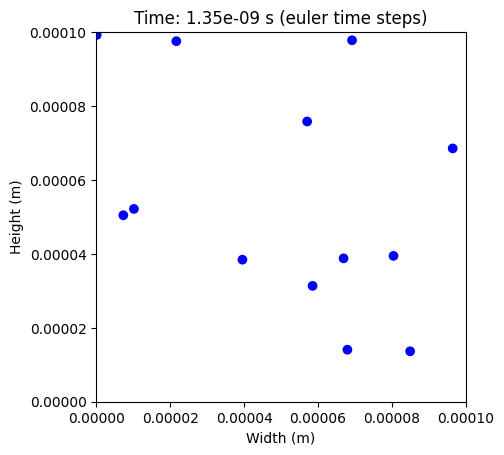

In [ ]:
# Create initial conditions
num_particles = 25
particle_speed = 1e6 # m/s

# Simulation parameters
container_size = 1e-4  # m
time_steps     = 300
dt             = 1e-12 # s

# Define fields
E_ext = np.array([1e5, 0.0, 0.0]) # N/C
B_ext = np.array([0.0, 0.0, 2e-1])  # T

# Initial particle conditions
positions  = np.random.rand(num_particles, 2) * container_size
velocities = (np.random.rand(num_particles, 2)-0.5) * particle_speed
charges    = np.random.choice([-1, 1], size=num_particles) * q
#charges    = np.full(num_particles, -q)
masses     = np.where(charges > 0, m_p, m_e)
colors     = np.where(charges > 0, 'blue', 'red')
run_sim(
    positions, velocities, E_ext, B_ext, 
    # Sim properties
    container_size, colors, num_particles, charges, masses,
    # Time properties
    dt, time_steps,
    "euler", False
)